# Simple Mars-Earth drainage-density presentation

A clean meeting notebook for discussing whether Martian mapped valley networks should be compared to full Earth drainage trees or to simplified higher-order Earth skeletons.


## 0. Setup

Paths and presentation parameters are kept here so the notebook can be adjusted before the meeting without editing the analysis code below.


In [12]:
from pathlib import Path
import os
import sys
import warnings

# Find the repository root from whichever directory Jupyter was launched in.
PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("CHANNEL_HEADS_ROOT", str(PROJECT_ROOT))

# Keep Matplotlib cache writes out of the home directory on locked-down machines.
MPLCONFIGDIR = Path("/private/tmp/channel_heads_mplconfig")
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from IPython.display import display, Markdown

from channel_heads.config import EXAMPLE_DEMS, RESULTS_DIR
from channel_heads.basin_config import LOCAL_TO_PAPER_BASIN, get_basin_config
from channel_heads.dd_calibration import (
    MARS_DD_STATS,
    STATUS_OK,
    basin_to_hull_area_ratio,
    collect_dd_hull_trim_for_dem,
    mars_network_geometry,
    mars_network_strahler,
    mars_network_table,
    run_practical_sweep,
    single_basin_threshold_geometry,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
DRAINAGE_RESULTS_DIR = RESULTS_DIR / "drainage_density_calibration"
COMPLEXITY_DIR = DRAINAGE_RESULTS_DIR / "complexity_calibration"
PRESENTATION_DIR = DRAINAGE_RESULTS_DIR / "simple_presentation"
FIGURE_DIR = PRESENTATION_DIR / "figures"
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MARS_GPKG = PROJECT_ROOT / "data" / "final_valleys" / "final_valleys_fixed.gpkg"
COMPLEXITY_CSV = COMPLEXITY_DIR / "dd_master_sweep_complexity.csv"
REGIME_GRID_CSV = COMPLEXITY_DIR / "regime_grid_summary.csv"
SIMPLE_REGIME_CSV = PRESENTATION_DIR / "simple_regime_summary.csv"

# ---------------------------------------------------------------------
# Presentation parameters: change these before the meeting if needed.
# ---------------------------------------------------------------------
SELECTED_THRESHOLDS = [0.1, 0.2, 0.5]
SELECTED_MIN_STRAHLER = [2, 3]
MAP_EXAMPLE_THRESHOLD = 0.2
MAP_EXAMPLE_MIN_STRAHLER_VALUES = [1, 2, 3]
N_EARTH_MAP_EXAMPLES = 4
N_MARS_MAP_EXAMPLES = 4
N_COMBINED_MAP_COMPARISONS = 3

# Fallback Earth examples if the automatic selector cannot find enough from the sweep.
# Each tuple is (basin_name, outlet_size_rank); rank 0 means largest basin.
MAP_EXAMPLE_BASINS = [("sakhalin", 0), ("inyo", 0), ("panamint", 0), ("troodos", 0)]

# Sweep settings used only if cached sweep outputs are missing.
BASINS = [name for name, path in EXAMPLE_DEMS.items() if path.exists()]
MIN_BASIN_PX = 1000
MAX_OUTLETS = 80
MIN_ORDERS = (2, 3, 4, 5)

C_MARS = "#b5533f"
C_EARTH = "#1f6fb4"
C_TRIM = "#2e8b57"
C_HULL = "#c77c2f"
C_BASIN = "#557f63"
C_GRAY = "#606060"

print(f"Project root: {PROJECT_ROOT}")
print(f"Presentation outputs: {PRESENTATION_DIR}")
print(f"Earth DEMs available: {len(BASINS)}")


Project root: /Users/guypi/Projects/channel-heads
Presentation outputs: /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation
Earth DEMs available: 17


In [13]:
def require_file(path, message):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"{message}\nMissing file: {path}")
    return path


def save_figure(fig, filename, dpi=170):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"saved {path}")
    return path


def load_or_build_master_sweep():
    if COMPLEXITY_CSV.exists():
        print(f"Loading cached Earth sweep: {COMPLEXITY_CSV}")
        return pd.read_csv(COMPLEXITY_CSV)
    if not BASINS:
        raise FileNotFoundError(
            "No cropped Earth DEMs were found. Run the DEM preparation step first."
        )
    print("Cached Earth sweep not found; running run_practical_sweep. This can take a while.")
    return run_practical_sweep(
        basins=BASINS,
        thresholds_km2=SELECTED_THRESHOLDS,
        cache_csv=COMPLEXITY_CSV,
        min_outlet_basin_pixels=MIN_BASIN_PX,
        max_outlets=MAX_OUTLETS,
        min_orders=MIN_ORDERS,
        verbose=True,
    )


def suffix_for_min_strahler(min_strahler):
    if int(min_strahler) <= 1:
        return "full"
    if int(min_strahler) == 2:
        return "trim"
    return f"ge{int(min_strahler)}"


def regime_label(row):
    return f"T={row['threshold']:g}, S≥{int(row['min_strahler_kept'])}"


def summarize_by_threshold(df, value_col):
    rows = []
    for threshold, group in df.groupby("threshold_km2", sort=True):
        values = group[value_col].replace([np.inf, -np.inf], np.nan).dropna()
        if values.empty:
            continue
        rows.append({
            "threshold_km2": float(threshold),
            "n": int(values.size),
            "q1": values.quantile(0.25),
            "median": values.median(),
            "q3": values.quantile(0.75),
        })
    return pd.DataFrame(rows)


def plot_threshold_series(ax, summary, title, ylabel, color=C_EARTH):
    x = summary["threshold_km2"].to_numpy(float)
    ax.plot(x, summary["median"], marker="o", lw=2, color=color)
    ax.fill_between(x, summary["q1"], summary["q3"], color=color, alpha=0.18, lw=0)
    ax.set_xscale("log")
    ax.set_xlabel("Extraction threshold (km²)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)


def normalize_regime_table(df):
    rename = {
        "threshold_km2": "threshold",
        "n_outlets": "n_networks",
        "median_dd_hull": "median_Dd_hull",
        "median_dd_true": "median_Dd_true",
        "median_basin_to_hull_ratio": "median_basin_to_hull_area_ratio",
        "median_pct_length_retained": "median_retained_length_pct",
        "pct_in_mars_iqr": "percent_inside_Mars_Dd_hull_IQR",
    }
    out = df.rename(columns=rename).copy()
    expected = [
        "threshold",
        "min_strahler_kept",
        "n_networks",
        "median_max_strahler",
        "median_Dd_hull",
        "median_Dd_true",
        "median_basin_to_hull_area_ratio",
        "median_retained_length_pct",
        "percent_inside_Mars_Dd_hull_IQR",
    ]
    missing = [c for c in expected if c not in out.columns]
    if missing:
        raise ValueError(f"Regime table is missing expected columns: {missing}")
    return out[expected]


def compute_regime_summary_from_master(master):
    rows = []
    q1, q3 = MARS_DD_STATS["q1"], MARS_DD_STATS["q3"]
    for threshold in SELECTED_THRESHOLDS:
        threshold_rows = master[np.isclose(master["threshold_km2"], threshold)]
        for min_s in SELECTED_MIN_STRAHLER:
            suffix = suffix_for_min_strahler(min_s)
            status_col = f"status_{suffix}"
            if status_col not in threshold_rows.columns:
                raise ValueError(
                    f"The cached sweep does not include Strahler ≥{min_s}. "
                    "Re-run the complexity sweep with MIN_ORDERS including this value."
                )
            sub = threshold_rows[threshold_rows[status_col] == STATUS_OK].copy()
            if sub.empty:
                rows.append({
                    "threshold": threshold,
                    "min_strahler_kept": min_s,
                    "n_networks": 0,
                    "median_max_strahler": np.nan,
                    "median_Dd_hull": np.nan,
                    "median_Dd_true": np.nan,
                    "median_basin_to_hull_area_ratio": np.nan,
                    "median_retained_length_pct": np.nan,
                    "percent_inside_Mars_Dd_hull_IQR": np.nan,
                })
                continue
            dd_hull = sub[f"dd_hull_{suffix}"].replace([np.inf, -np.inf], np.nan).dropna()
            dd_true = sub.loc[dd_hull.index, f"dd_true_{suffix}"]
            max_s = sub[f"max_strahler_{suffix}"].replace([np.inf, -np.inf], np.nan).dropna()
            retained = pd.Series(100.0, index=sub.index) if suffix == "full" else sub[f"pct_length_{suffix}"]
            basin_to_hull = basin_to_hull_area_ratio(dd_hull.to_numpy(), dd_true.to_numpy())
            rows.append({
                "threshold": threshold,
                "min_strahler_kept": min_s,
                "n_networks": int(len(sub)),
                "median_max_strahler": int(max_s.median()) if len(max_s) else np.nan,
                "median_Dd_hull": round(float(dd_hull.median()), 3) if len(dd_hull) else np.nan,
                "median_Dd_true": round(float(dd_true.median()), 3) if len(dd_true) else np.nan,
                "median_basin_to_hull_area_ratio": round(float(np.nanmedian(basin_to_hull)), 3),
                "median_retained_length_pct": round(float(retained.median()), 1),
                "percent_inside_Mars_Dd_hull_IQR": round(float(100 * ((dd_hull >= q1) & (dd_hull <= q3)).mean()), 1),
            })
    return pd.DataFrame(rows)


_BARS = np.array([0.2, 0.5, 1, 2, 5, 10, 20, 50, 100])


def geometry_bounds(*arrays):
    pts = []
    for arr in arrays:
        if arr is None:
            continue
        arr = np.asarray(arr)
        if arr.size:
            pts.append(arr.reshape(-1, 2))
    if not pts:
        return np.array([0.0, 0.0]), 1.0
    pts = np.vstack(pts)
    lo, hi = pts.min(axis=0), pts.max(axis=0)
    center = (lo + hi) / 2.0
    half = max(float((hi - lo).max()) / 2.0, 1.0) * 1.12
    return center, half


def draw_network_panel(ax, *, variant, basin_boundary_xy=None, outlet_xy=None, title="", center=None, half=None):
    if center is None or half is None:
        center, half = geometry_bounds(
            variant.get("stream_seg"), variant.get("hull_xy"), basin_boundary_xy, outlet_xy
        )

    def to_km(arr):
        return (np.asarray(arr) - center) / 1000.0

    if basin_boundary_xy is not None:
        b = to_km(basin_boundary_xy)
        ax.plot(b[:, 0], b[:, 1], color=C_BASIN, lw=1.0, alpha=0.95)

    stream_segments = variant.get("stream_seg")
    if stream_segments is not None and len(stream_segments):
        n_segments = len(stream_segments)
        lw = float(np.clip(42.0 / np.sqrt(max(n_segments, 1)), 0.18, 1.1))
        ax.add_collection(
            LineCollection(to_km(stream_segments), colors=C_EARTH, linewidths=lw, alpha=0.95)
        )

    hull_xy = variant.get("hull_xy")
    if hull_xy is not None and len(hull_xy):
        h = to_km(np.vstack([hull_xy, hull_xy[:1]]))
        ax.plot(h[:, 0], h[:, 1], "--", color=C_HULL, lw=1.3)
        ax.fill(h[:, 0], h[:, 1], color=C_HULL, alpha=0.08)

    if outlet_xy is not None:
        p = to_km(np.asarray(outlet_xy).reshape(1, 2))[0]
        ax.scatter([p[0]], [p[1]], s=24, color="black", zorder=5)

    hk = half / 1000.0
    ax.set_xlim(-hk, hk)
    ax.set_ylim(-hk, hk)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)

    scale = _BARS[np.argmin(np.abs(_BARS - hk / 2.5))]
    x0, y0 = -hk * 0.90, -hk * 0.90
    ax.plot([x0, x0 + scale], [y0, y0], color="black", lw=2.0)
    ax.text(x0 + scale / 2, y0 + hk * 0.035, f"{scale:g} km", ha="center", va="bottom", fontsize=7)



def stacked_line_points(lines):
    if not lines:
        return None
    parts = [np.asarray(line)[:, :2] for line in lines if np.asarray(line).size]
    if not parts:
        return None
    return np.vstack(parts)


def draw_mars_panel(ax, *, lines, hull_xy=None, title="", center=None, half=None):
    line_points = stacked_line_points(lines)
    if center is None or half is None:
        center, half = geometry_bounds(line_points, hull_xy)

    def to_km(arr):
        return (np.asarray(arr) - center) / 1000.0

    if lines:
        segments = [to_km(np.asarray(line)[:, :2]) for line in lines if np.asarray(line).shape[0] >= 2]
        if segments:
            lw = float(np.clip(12.0 / np.sqrt(max(len(segments), 1)), 0.7, 1.8))
            ax.add_collection(LineCollection(segments, colors=C_MARS, linewidths=lw, alpha=0.96))

    if hull_xy is not None and len(hull_xy):
        h = to_km(np.vstack([hull_xy, hull_xy[:1]]))
        ax.plot(h[:, 0], h[:, 1], "--", color=C_HULL, lw=1.3)
        ax.fill(h[:, 0], h[:, 1], color=C_HULL, alpha=0.08)

    hk = half / 1000.0
    ax.set_xlim(-hk, hk)
    ax.set_ylim(-hk, hk)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)

    scale = _BARS[np.argmin(np.abs(_BARS - hk / 2.5))]
    x0, y0 = -hk * 0.90, -hk * 0.90
    ax.plot([x0, x0 + scale], [y0, y0], color="black", lw=2.0)
    ax.text(x0 + scale / 2, y0 + hk * 0.035, f"{scale:g} km", ha="center", va="bottom", fontsize=7)


## 1. Scientific framing

Mars data are mapped valley networks: preserved valley systems that are visible and interpretable in imagery and topography.

Earth data here are DEM-extracted drainage networks: full dendritic drainage trees produced from a contributing-area threshold.

These are not equivalent objects. A direct Earth-Mars match in `Dd_hull` can therefore confuse two issues: real drainage density and the different kinds of networks being compared.

The goal of this notebook is to compare Earth full networks and simplified higher-order Earth skeletons against Mars. `Dd_hull` is treated as a mapped-network proxy, not as true watershed drainage density.


## 2. Mars baseline

First, define the Mars mapped-network reference distribution: length of mapped valleys divided by convex-hull area around each mapped network.


In [14]:
require_file(MARS_GPKG, "Mars mapped valley-network GeoPackage is required for the baseline.")

mars_dd = mars_network_table(MARS_GPKG)
mars_ok = mars_dd[mars_dd["status"] == STATUS_OK].copy()

try:
    mars_strahler = mars_network_strahler(MARS_GPKG)
    mars_strahler_ok = mars_strahler[mars_strahler["status"] == STATUS_OK].copy()
except Exception as exc:
    mars_strahler = pd.DataFrame()
    mars_strahler_ok = pd.DataFrame()
    print(f"Mars max-Strahler summary not available: {exc}")

mars_summary = pd.DataFrame([{
    "n_martian_networks": int(len(mars_ok)),
    "median_Dd_hull": mars_ok["dd_hull_km_km2"].median(),
    "IQR_Dd_hull": mars_ok["dd_hull_km_km2"].quantile(0.75) - mars_ok["dd_hull_km_km2"].quantile(0.25),
    "q1_Dd_hull": mars_ok["dd_hull_km_km2"].quantile(0.25),
    "q3_Dd_hull": mars_ok["dd_hull_km_km2"].quantile(0.75),
    "mean_Dd_hull": mars_ok["dd_hull_km_km2"].mean(),
}])
display(mars_summary.round(4))

if not mars_strahler_ok.empty:
    display(mars_strahler_ok["max_strahler"].value_counts().sort_index().to_frame("n_networks"))


,n_martian_networks,median_Dd_hull,IQR_Dd_hull,q1_Dd_hull,q3_Dd_hull,mean_Dd_hull
0,391,0.2239,0.1375,0.1612,0.2987,0.2419


,n_networks
max_strahler,
2,13
3,338
4,38
5,2


saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_mars_dd_hull_distribution.png


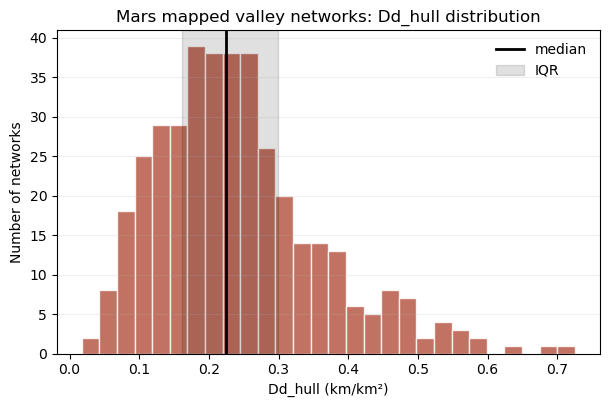

saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_mars_max_strahler_order.png


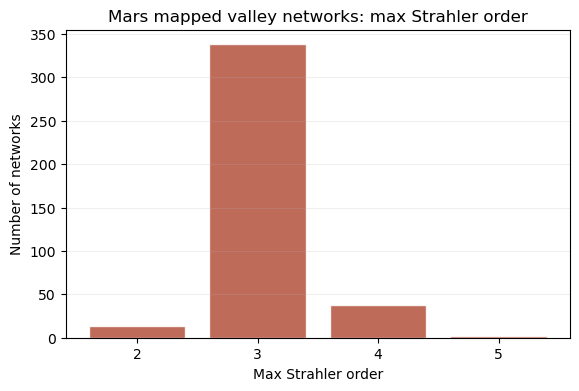

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.2))
values = mars_ok["dd_hull_km_km2"].dropna()
ax.hist(values, bins=28, color=C_MARS, alpha=0.82, edgecolor="white")
ax.axvline(MARS_DD_STATS["median"], color="black", lw=2, label="median")
ax.axvspan(MARS_DD_STATS["q1"], MARS_DD_STATS["q3"], color="black", alpha=0.12, label="IQR")
ax.set_title("Mars mapped valley networks: Dd_hull distribution")
ax.set_xlabel("Dd_hull (km/km²)")
ax.set_ylabel("Number of networks")
ax.legend(frameon=False)
ax.grid(True, axis="y", alpha=0.2)
save_figure(fig, "fig_mars_dd_hull_distribution.png")
plt.show()

if not mars_strahler_ok.empty:
    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    counts = mars_strahler_ok["max_strahler"].value_counts().sort_index()
    ax.bar(counts.index.astype(int), counts.values, color=C_MARS, alpha=0.86, edgecolor="white")
    ax.set_title("Mars mapped valley networks: max Strahler order")
    ax.set_xlabel("Max Strahler order")
    ax.set_ylabel("Number of networks")
    ax.set_xticks(counts.index.astype(int))
    ax.grid(True, axis="y", alpha=0.2)
    save_figure(fig, "fig_mars_max_strahler_order.png")
    plt.show()


## 3. Earth threshold sweep, full networks

This is the baseline Earth extraction before Strahler pruning. The purpose is to show that full DEM-derived Earth networks change strongly with threshold and are commonly more complex than the mapped Martian networks.


In [16]:
master = load_or_build_master_sweep()
full = master[master["status_full"] == STATUS_OK].copy()
if full.empty:
    raise ValueError("No valid full-network rows found in the Earth sweep cache.")

full["basin_to_hull_area_ratio_full"] = basin_to_hull_area_ratio(
    full["dd_hull_full"].to_numpy(), full["dd_true_full"].to_numpy()
)

threshold_table = pd.DataFrame({
    "threshold_km2": sorted(full["threshold_km2"].unique()),
})
threshold_table = threshold_table.merge(
    summarize_by_threshold(full, "dd_hull_full")[["threshold_km2", "n", "median"]]
    .rename(columns={"n": "n_networks", "median": "median_Dd_hull"}),
    on="threshold_km2",
    how="left",
).merge(
    summarize_by_threshold(full, "dd_true_full")[["threshold_km2", "median"]]
    .rename(columns={"median": "median_Dd_true"}),
    on="threshold_km2",
    how="left",
).merge(
    summarize_by_threshold(full, "max_strahler_full")[["threshold_km2", "median"]]
    .rename(columns={"median": "median_max_strahler"}),
    on="threshold_km2",
    how="left",
).merge(
    summarize_by_threshold(full, "basin_to_hull_area_ratio_full")[["threshold_km2", "median"]]
    .rename(columns={"median": "median_basin_to_hull_area_ratio"}),
    on="threshold_km2",
    how="left",
)

display(threshold_table.round(3))


Loading cached Earth sweep: /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/complexity_calibration/dd_master_sweep_complexity.csv


,threshold_km2,n_networks,median_Dd_hull,median_Dd_true,median_max_strahler,median_basin_to_hull_area_ratio
0,0.0100,513,11.1060,13.0980,6.0000,0.8720
1,0.0250,513,5.1070,5.5550,5.0000,0.9510
2,0.0500,513,3.1460,3.1490,5.0000,1.0130
3,0.1000,513,2.2520,2.0310,4.0000,1.1090
4,0.2000,513,1.8200,1.4330,4.0000,1.2420
5,0.5000,513,1.4770,0.9410,3.0000,1.5110
6,1.0000,513,1.3650,0.6890,3.0000,1.9100
7,2.0000,513,1.4660,0.4980,2.0000,2.7240
8,5.0000,512,2.1470,0.3050,1.0000,6.5510
9,10.0000,422,2.5990,0.2070,1.0000,12.1320


saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_earth_full_threshold_sweep.png


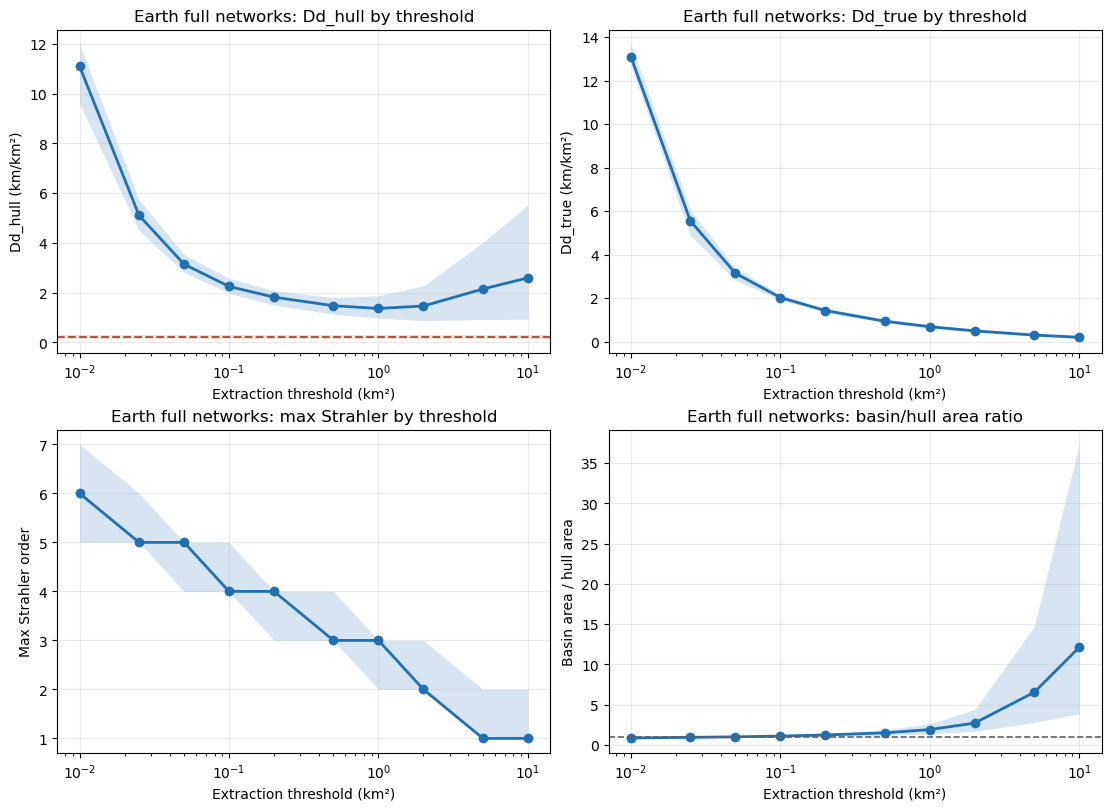

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
plot_threshold_series(
    axes[0, 0], summarize_by_threshold(full, "dd_hull_full"),
    "Earth full networks: Dd_hull by threshold", "Dd_hull (km/km²)", C_EARTH,
)
axes[0, 0].axhspan(MARS_DD_STATS["q1"], MARS_DD_STATS["q3"], color=C_MARS, alpha=0.10)
axes[0, 0].axhline(MARS_DD_STATS["median"], color=C_MARS, ls="--", lw=1.5)

plot_threshold_series(
    axes[0, 1], summarize_by_threshold(full, "dd_true_full"),
    "Earth full networks: Dd_true by threshold", "Dd_true (km/km²)", C_EARTH,
)
plot_threshold_series(
    axes[1, 0], summarize_by_threshold(full, "max_strahler_full"),
    "Earth full networks: max Strahler by threshold", "Max Strahler order", C_EARTH,
)
plot_threshold_series(
    axes[1, 1], summarize_by_threshold(full, "basin_to_hull_area_ratio_full"),
    "Earth full networks: basin/hull area ratio", "Basin area / hull area", C_EARTH,
)
axes[1, 1].axhline(1.0, color=C_GRAY, ls="--", lw=1.2)

save_figure(fig, "fig_earth_full_threshold_sweep.png")
plt.show()


## 4. Fixed regime comparison

This is the main comparison. Instead of optimizing one threshold, evaluate a small set of fixed regimes: extraction threshold × minimum Strahler order kept.


In [18]:
needed_pairs = {(float(t), int(s)) for t in SELECTED_THRESHOLDS for s in SELECTED_MIN_STRAHLER}

if REGIME_GRID_CSV.exists():
    print(f"Loading cached regime grid: {REGIME_GRID_CSV}")
    regime_table = normalize_regime_table(pd.read_csv(REGIME_GRID_CSV))
    regime_table = regime_table[
        regime_table.apply(lambda r: (float(r["threshold"]), int(r["min_strahler_kept"])) in needed_pairs, axis=1)
    ].copy()
    have_pairs = {(float(r.threshold), int(r.min_strahler_kept)) for r in regime_table.itertuples()}
else:
    have_pairs = set()

if have_pairs != needed_pairs:
    missing = sorted(needed_pairs - have_pairs)
    print(f"Cached regime grid is missing {missing}; computing selected regimes from master sweep.")
    regime_table = compute_regime_summary_from_master(master)

regime_table = regime_table.sort_values(["threshold", "min_strahler_kept"]).reset_index(drop=True)
regime_table.to_csv(SIMPLE_REGIME_CSV, index=False)

print(f"Saved clean regime table: {SIMPLE_REGIME_CSV}")
display(regime_table.round(3))


Loading cached regime grid: /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/complexity_calibration/regime_grid_summary.csv
Saved clean regime table: /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/simple_regime_summary.csv


,threshold,min_strahler_kept,n_networks,median_max_strahler,median_Dd_hull,median_Dd_true,median_basin_to_hull_area_ratio,median_retained_length_pct,percent_inside_Mars_Dd_hull_IQR
0,0.1000,2,513,3,1.4740,0.9920,1.4520,48.6000,0.0000
1,0.1000,3,511,2,1.3810,0.4960,2.5630,24.3000,0.0000
2,0.2000,2,513,3,1.3250,0.7090,1.8090,49.8000,0.0000
3,0.2000,3,484,2,1.7580,0.3420,4.6700,23.9000,0.4000
4,0.5000,2,511,2,1.4980,0.4640,2.9060,49.4000,0.0000
5,0.5000,3,392,1,2.3140,0.2180,9.4630,23.7000,3.3000


saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_fixed_regime_comparison.png


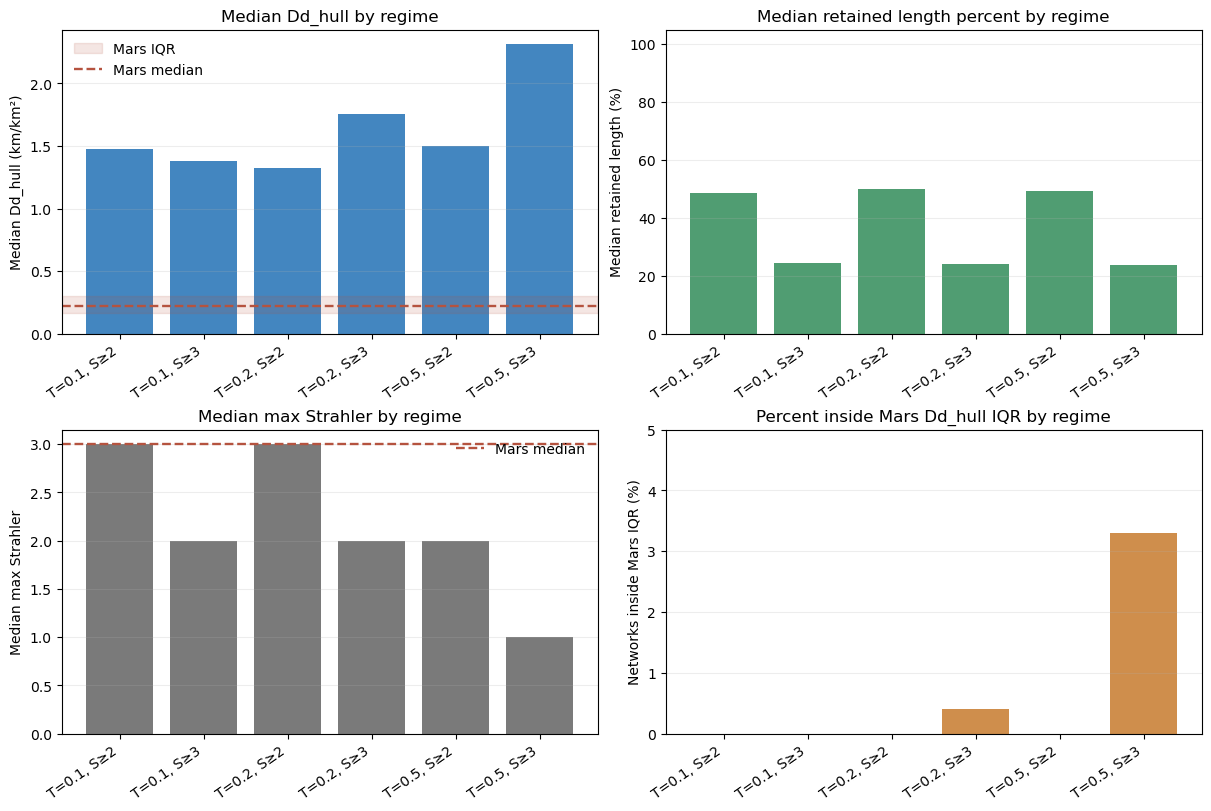

In [19]:
labels = [regime_label(row) for _, row in regime_table.iterrows()]
x = np.arange(len(regime_table))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

ax = axes[0, 0]
ax.bar(x, regime_table["median_Dd_hull"], color=C_EARTH, alpha=0.84)
ax.axhspan(MARS_DD_STATS["q1"], MARS_DD_STATS["q3"], color=C_MARS, alpha=0.14, label="Mars IQR")
ax.axhline(MARS_DD_STATS["median"], color=C_MARS, ls="--", lw=1.7, label="Mars median")
ax.set_title("Median Dd_hull by regime")
ax.set_ylabel("Median Dd_hull (km/km²)")
ax.legend(frameon=False)

ax = axes[0, 1]
ax.bar(x, regime_table["median_retained_length_pct"], color=C_TRIM, alpha=0.84)
ax.set_title("Median retained length percent by regime")
ax.set_ylabel("Median retained length (%)")
ax.set_ylim(0, max(105, regime_table["median_retained_length_pct"].max() * 1.12))

ax = axes[1, 0]
ax.bar(x, regime_table["median_max_strahler"], color=C_GRAY, alpha=0.84)
if not mars_strahler_ok.empty:
    ax.axhline(mars_strahler_ok["max_strahler"].median(), color=C_MARS, ls="--", lw=1.7, label="Mars median")
    ax.legend(frameon=False)
ax.set_title("Median max Strahler by regime")
ax.set_ylabel("Median max Strahler")

ax = axes[1, 1]
ax.bar(x, regime_table["percent_inside_Mars_Dd_hull_IQR"], color=C_HULL, alpha=0.86)
ax.set_title("Percent inside Mars Dd_hull IQR by regime")
ax.set_ylabel("Networks inside Mars IQR (%)")
ax.set_ylim(0, max(5, regime_table["percent_inside_Mars_Dd_hull_IQR"].max() * 1.25))

for ax in axes.ravel():
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.grid(True, axis="y", alpha=0.22)

save_figure(fig, "fig_fixed_regime_comparison.png")
plt.show()


## 5. Clean map comparison

These maps keep the extraction threshold fixed and show how Strahler pruning turns a dense Earth drainage tree into a higher-order skeleton. This is the visual basis for asking whether mapped Martian valleys are closer to full Earth trees or to pruned Earth skeletons.


saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_earth_simplification_example_01.png


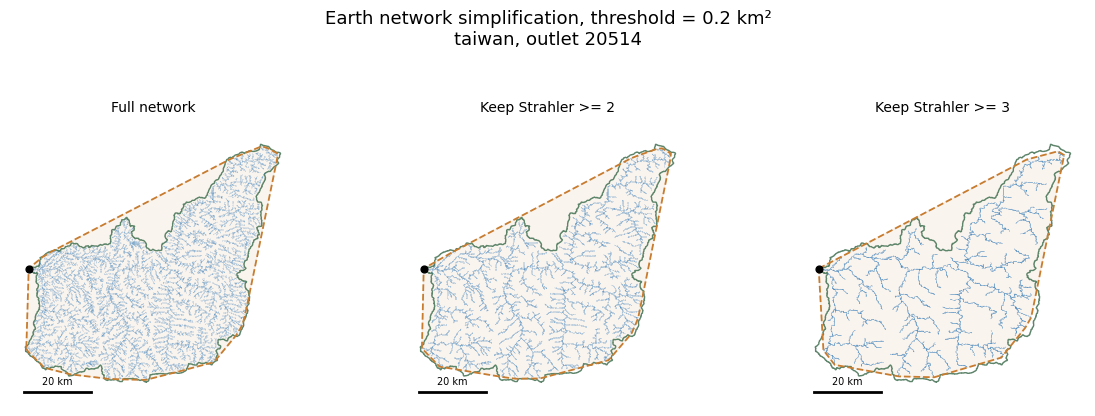

saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_earth_simplification_example_02.png


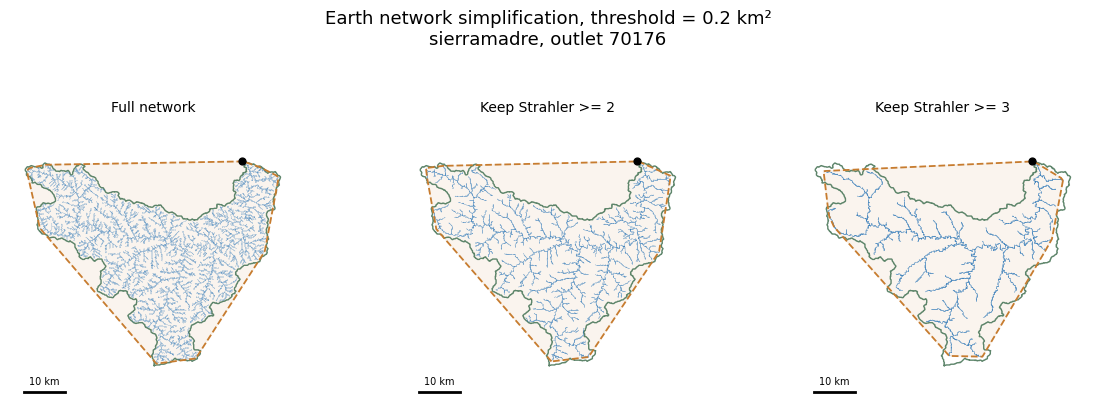

saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_earth_simplification_example_03.png


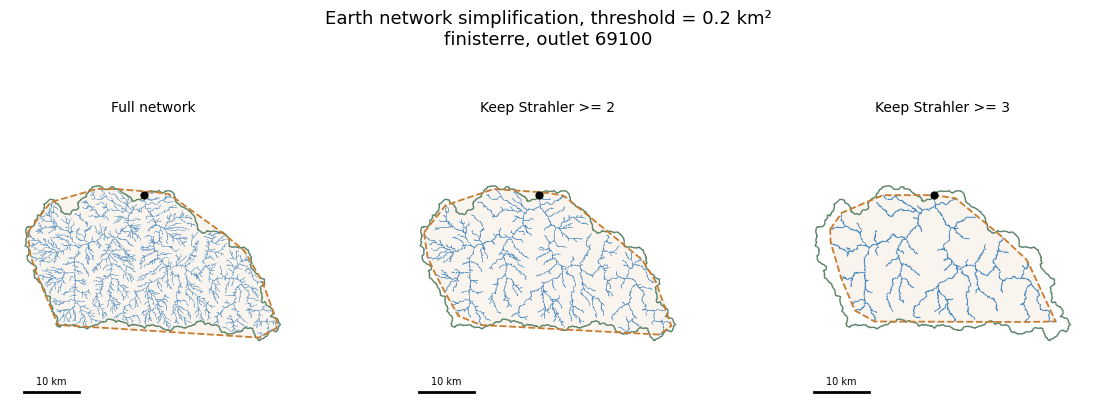

saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_earth_simplification_example_04.png


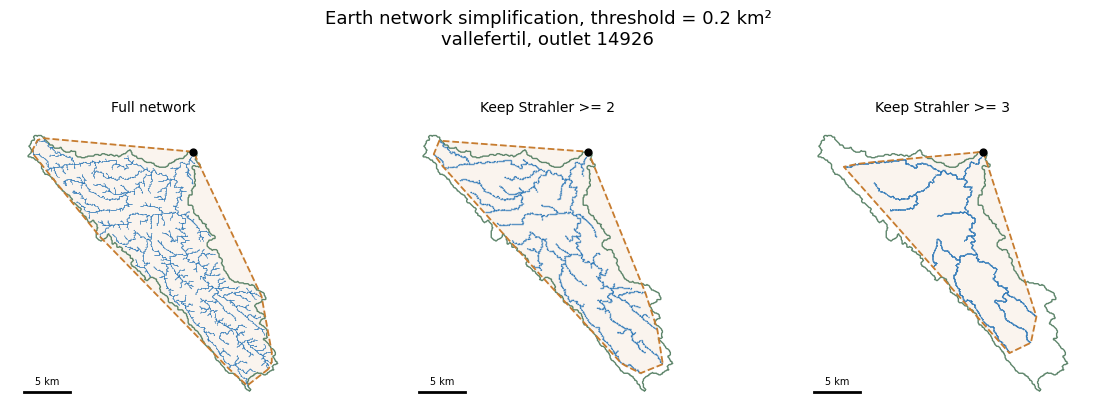

Generated 4 Earth map examples.


In [20]:

map_variant_titles = {
    1: "Full network",
    2: "Keep Strahler >= 2",
    3: "Keep Strahler >= 3",
}


def nearest_available_threshold(target, values):
    values = np.asarray(sorted(pd.Series(values).dropna().unique()), dtype=float)
    if values.size == 0:
        raise ValueError("No thresholds are available in the Earth sweep table.")
    return float(values[np.argmin(np.abs(values - float(target)))])


def select_earth_map_candidates(master_df, n_examples, target_threshold):
    used_threshold = nearest_available_threshold(target_threshold, master_df["threshold_km2"])
    rows = master_df[np.isclose(master_df["threshold_km2"], used_threshold)].copy()

    required = [
        "status_full", "status_trim", "status_ge3", "length_km_full", "length_km_ge3",
        "hull_area_km2_full", "hull_area_km2_ge3", "pct_length_ge3", "max_strahler_full",
        "dem_name", "outlet_node",
    ]
    missing = [col for col in required if col not in rows.columns]
    if missing:
        print(f"Cannot auto-select Earth map examples; missing columns: {missing}")
        return [], used_threshold

    rows = rows[
        (rows["status_full"] == STATUS_OK)
        & (rows["status_trim"] == STATUS_OK)
        & (rows["status_ge3"] == STATUS_OK)
    ].copy()
    for col in [
        "length_km_full", "length_km_ge3", "hull_area_km2_full", "hull_area_km2_ge3",
        "pct_length_ge3", "max_strahler_full",
    ]:
        rows[col] = pd.to_numeric(rows[col], errors="coerce")

    rows = rows[
        (rows["length_km_full"] > 0)
        & (rows["length_km_ge3"] > 0)
        & (rows["hull_area_km2_full"] > 0)
        & (rows["hull_area_km2_ge3"] > 0)
        & (rows["pct_length_ge3"] >= 10)
    ].copy()
    if rows.empty:
        return [], used_threshold

    rows["map_score"] = (
        np.log1p(rows["length_km_full"])
        + 1.5 * np.log1p(rows["length_km_ge3"])
        + 0.5 * np.log1p(rows["hull_area_km2_full"])
        + 0.2 * rows["max_strahler_full"]
    )
    rows = rows.sort_values("map_score", ascending=False)

    selected = []
    used_basins = set()
    for _, row in rows.iterrows():
        if row["dem_name"] in used_basins:
            continue
        selected.append(row)
        used_basins.add(row["dem_name"])
        if len(selected) >= n_examples:
            break

    if len(selected) < n_examples:
        used_pairs = {(str(r["dem_name"]), int(r["outlet_node"])) for r in selected}
        for _, row in rows.iterrows():
            pair = (str(row["dem_name"]), int(row["outlet_node"]))
            if pair in used_pairs:
                continue
            selected.append(row)
            used_pairs.add(pair)
            if len(selected) >= n_examples:
                break

    return selected, used_threshold


def flat_earth_variant(row, suffix):
    return {
        "status": row.get(f"status_{suffix}"),
        "stream_seg": row.get(f"stream_seg_{suffix}"),
        "hull_xy": row.get(f"hull_xy_{suffix}"),
        "dd_hull": row.get(f"dd_hull_{suffix}", np.nan),
        "dd_true": row.get(f"dd_true_{suffix}", np.nan),
        "max_strahler": row.get(f"max_strahler_{suffix}", np.nan),
    }


earth_candidates, earth_map_threshold = select_earth_map_candidates(
    master, N_EARTH_MAP_EXAMPLES, MAP_EXAMPLE_THRESHOLD
)
if not np.isclose(earth_map_threshold, MAP_EXAMPLE_THRESHOLD):
    print(
        f"Requested Earth map threshold {MAP_EXAMPLE_THRESHOLD:g} km² was not in the sweep; "
        f"using nearest available threshold {earth_map_threshold:g} km²."
    )

earth_map_examples = []
for row in earth_candidates:
    basin_name = str(row["dem_name"])
    outlet_node = int(row["outlet_node"])
    if basin_name not in BASINS:
        continue

    cfg = get_basin_config(LOCAL_TO_PAPER_BASIN.get(basin_name, basin_name))
    recs = collect_dd_hull_trim_for_dem(
        dem_path=EXAMPLE_DEMS[basin_name],
        basin_name=basin_name,
        threshold_km2=earth_map_threshold,
        z_th=cfg["z_th"],
        lat_deg=float(cfg["lat"]),
        min_outlet_basin_pixels=MIN_BASIN_PX,
        max_outlets=MAX_OUTLETS,
        geometry_for_outlets={outlet_node},
    )
    match = [rec for rec in recs if int(rec.get("outlet_node", -1)) == outlet_node]
    if not match:
        print(f"Skipping {basin_name} outlet {outlet_node}: geometry was not returned.")
        continue
    rec = match[0]
    variants = {
        "full": flat_earth_variant(rec, "full"),
        "trim": flat_earth_variant(rec, "trim"),
        "ge3": flat_earth_variant(rec, "ge3"),
    }
    if any(variants[key]["status"] != STATUS_OK for key in ("full", "trim", "ge3")):
        print(f"Skipping {basin_name} outlet {outlet_node}: one pruning variant is invalid.")
        continue

    earth_map_examples.append({
        "dem_name": basin_name,
        "outlet_node": outlet_node,
        "threshold_km2": earth_map_threshold,
        "basin_boundary_xy": rec.get("basin_boundary_xy"),
        "outlet_xy": rec.get("outlet_xy"),
        "variants": variants,
    })

    fig_index = len(earth_map_examples)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
    center, half = geometry_bounds(
        variants["full"].get("stream_seg"),
        rec.get("basin_boundary_xy"),
        rec.get("outlet_xy"),
    )
    for ax, min_s in zip(axes, MAP_EXAMPLE_MIN_STRAHLER_VALUES):
        suffix = "full" if int(min_s) <= 1 else ("trim" if int(min_s) == 2 else f"ge{int(min_s)}")
        draw_network_panel(
            ax,
            variant=variants[suffix],
            basin_boundary_xy=rec.get("basin_boundary_xy"),
            outlet_xy=rec.get("outlet_xy"),
            title=map_variant_titles.get(min_s, f"Keep Strahler >= {min_s}"),
            center=center,
            half=half,
        )

    threshold_label = f"{earth_map_threshold:g} km²"
    if not np.isclose(earth_map_threshold, MAP_EXAMPLE_THRESHOLD):
        threshold_label += f" (nearest to requested {MAP_EXAMPLE_THRESHOLD:g} km²)"
    fig.suptitle(
        f"Earth network simplification, threshold = {threshold_label}\n"
        f"{basin_name}, outlet {outlet_node}",
        fontsize=13,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.88])
    save_figure(fig, f"fig_earth_simplification_example_{fig_index:02d}.png", dpi=180)
    plt.show()

print(f"Generated {len(earth_map_examples)} Earth map examples.")


## 6. Mars-Earth map comparison

These maps are not meant as one-to-one geographic matches. They are visual analogues used to compare mapped Mars valley networks with progressively simplified Earth drainage networks.


saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_mars_network_example_01.png


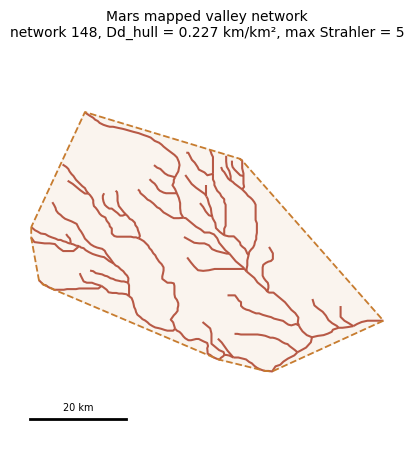

saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_mars_network_example_02.png


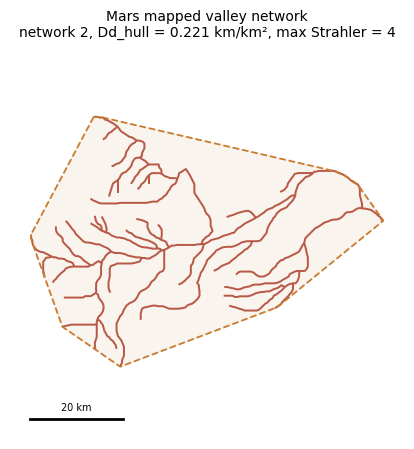

saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_mars_network_example_03.png


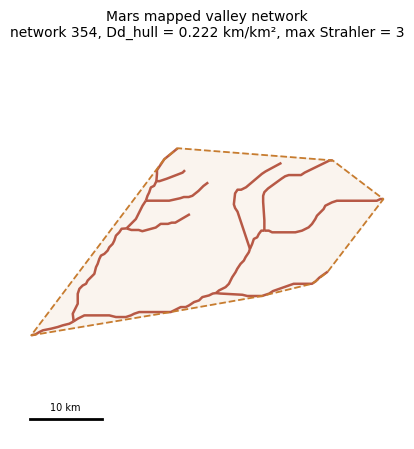

saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_mars_network_example_04.png


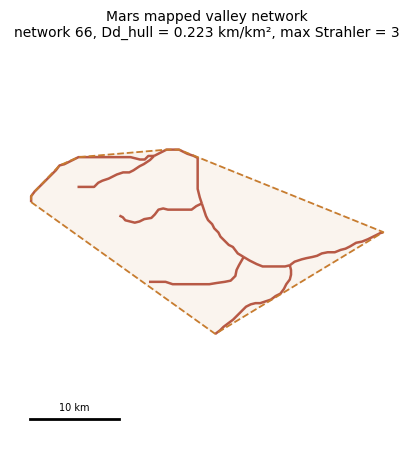

Generated 4 Mars map examples.


In [21]:
mars_map_examples = []

if not MARS_GPKG.exists():
    display(Markdown(
        "**Warning:** Mars map examples could not be generated because the mapped Mars geometry file was not found."
    ))
else:
    mars_geom = mars_network_geometry(MARS_GPKG)
    mars_map_table = mars_ok.rename(columns={"dd_hull_km_km2": "dd_hull"}).copy()
    if not mars_strahler_ok.empty and "max_strahler" in mars_strahler_ok.columns:
        mars_map_table = mars_map_table.merge(
            mars_strahler_ok[["network_id", "max_strahler", "n_leaves"]],
            on="network_id",
            how="left",
        )

    mars_map_table = mars_map_table[
        mars_map_table["network_id"].isin(mars_geom.keys())
        & np.isfinite(mars_map_table["dd_hull"])
        & np.isfinite(mars_map_table["length_km"])
        & np.isfinite(mars_map_table["hull_area_km2"])
    ].copy()

    q1, q3 = MARS_DD_STATS["q1"], MARS_DD_STATS["q3"]
    median = MARS_DD_STATS["median"]
    pool = mars_map_table[
        mars_map_table["dd_hull"].between(q1, q3)
        & (mars_map_table["length_km"] >= mars_map_table["length_km"].quantile(0.35))
    ].copy()
    if len(pool) < N_MARS_MAP_EXAMPLES:
        pool = mars_map_table.copy()

    iqr = max(q3 - q1, 1e-9)
    max_len = max(float(mars_map_table["length_km"].max()), 1.0)
    pool["map_score"] = (
        (pool["dd_hull"] - median).abs() / iqr
        - 0.15 * np.log1p(pool["length_km"]) / np.log1p(max_len)
    )
    if "max_strahler" in pool.columns:
        pool["map_score"] -= 0.05 * pool["max_strahler"].fillna(0)

    selected_mars = pool.sort_values("map_score").head(N_MARS_MAP_EXAMPLES)
    for fig_index, row in enumerate(selected_mars.itertuples(index=False), start=1):
        network_id = int(row.network_id)
        geom = mars_geom[network_id]
        max_s = getattr(row, "max_strahler", np.nan)
        strahler_text = "" if pd.isna(max_s) else f", max Strahler = {int(max_s)}"
        title = (
            "Mars mapped valley network\n"
            f"network {network_id}, Dd_hull = {row.dd_hull:.3f} km/km²{strahler_text}"
        )

        mars_map_examples.append({
            "network_id": network_id,
            "dd_hull": float(row.dd_hull),
            "max_strahler": None if pd.isna(max_s) else int(max_s),
            "lines": geom["lines"],
            "hull_xy": geom["hull_xy"],
            "length_km": float(row.length_km),
            "hull_area_km2": float(row.hull_area_km2),
        })

        fig, ax = plt.subplots(figsize=(4.8, 4.6))
        draw_mars_panel(ax, lines=geom["lines"], hull_xy=geom["hull_xy"], title=title)
        fig.tight_layout()
        save_figure(fig, f"fig_mars_network_example_{fig_index:02d}.png", dpi=180)
        plt.show()

print(f"Generated {len(mars_map_examples)} Mars map examples.")


### Combined visual analogues

The panels below place selected Mars mapped networks beside Earth full and pruned networks. The Mars and Earth panels use independent local map extents, so the comparison is about network form and simplification, not exact geographic scale or a matched location.


saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_mars_earth_visual_comparison_01.png


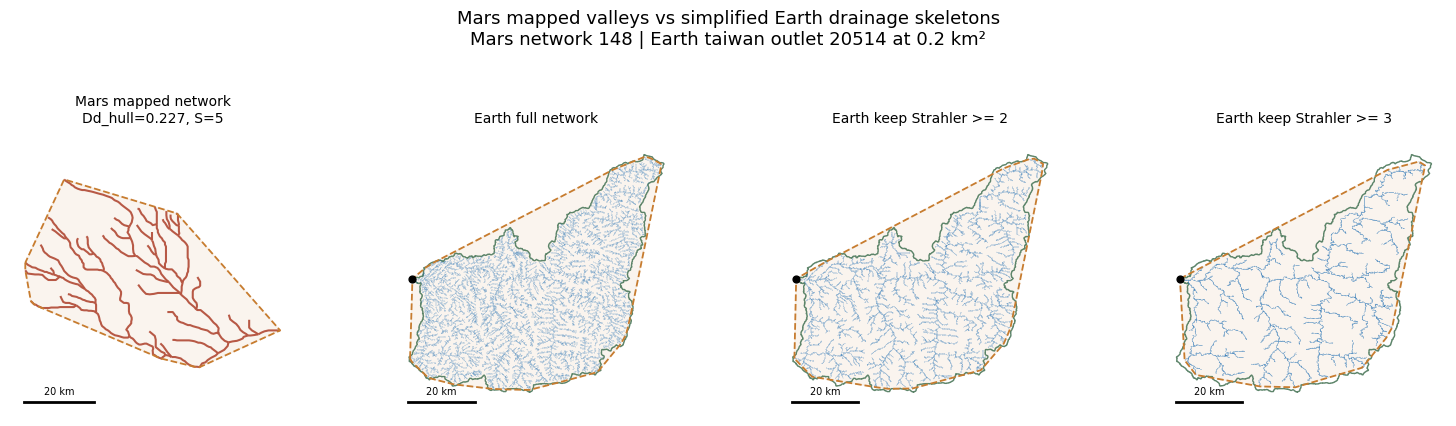

saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_mars_earth_visual_comparison_02.png


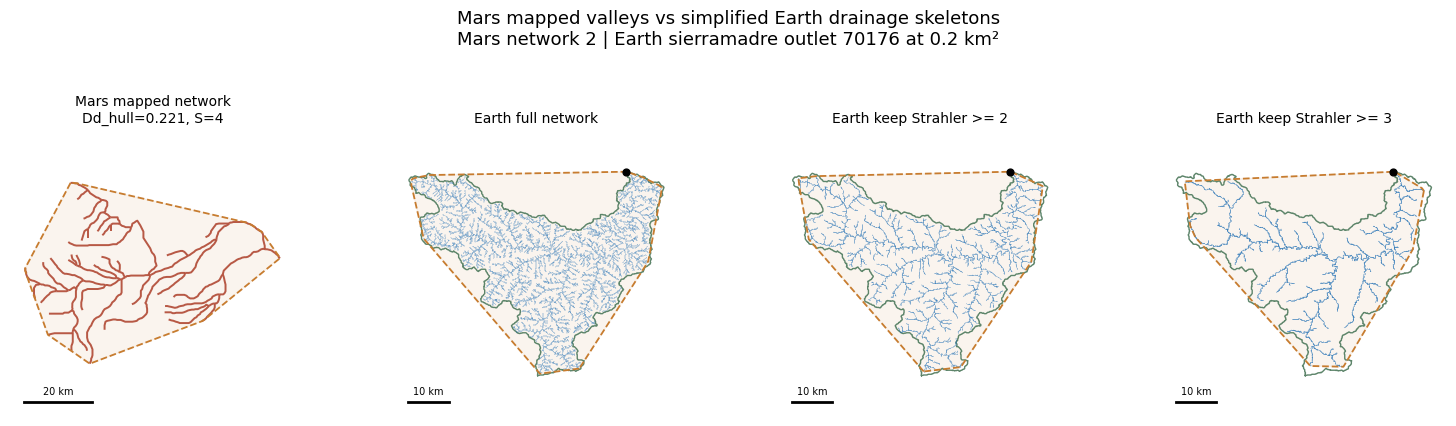

saved /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/simple_presentation/figures/fig_mars_earth_visual_comparison_03.png


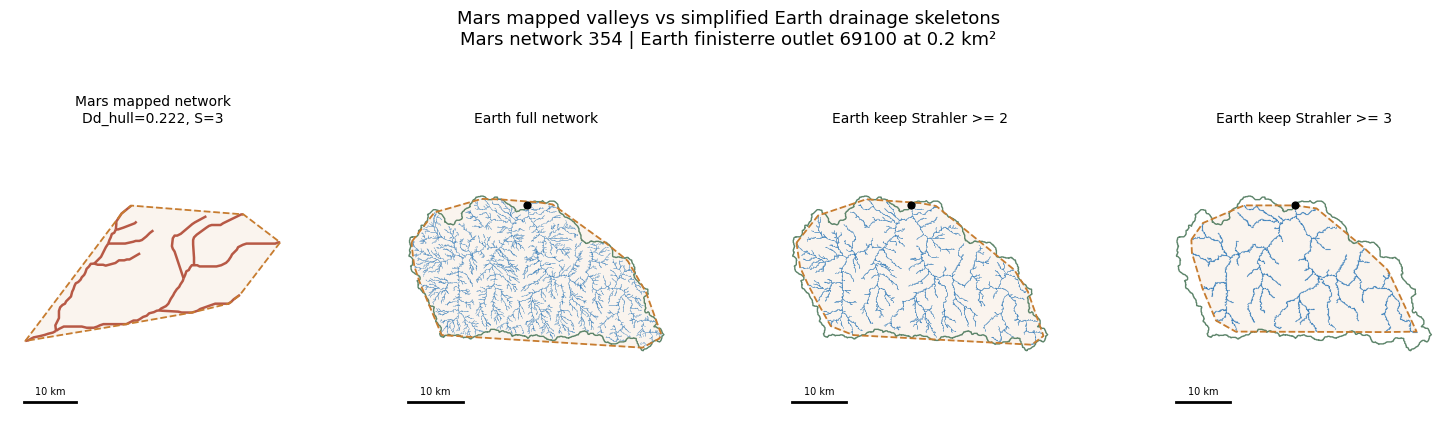

In [22]:
n_combined = min(N_COMBINED_MAP_COMPARISONS, len(mars_map_examples), len(earth_map_examples))
if n_combined == 0:
    print("Combined Mars-Earth maps could not be generated from the available examples.")
else:
    for fig_index in range(1, n_combined + 1):
        mars_ex = mars_map_examples[fig_index - 1]
        earth_ex = earth_map_examples[fig_index - 1]
        variants = earth_ex["variants"]
        e_center, e_half = geometry_bounds(
            variants["full"].get("stream_seg"),
            earth_ex.get("basin_boundary_xy"),
            earth_ex.get("outlet_xy"),
        )

        fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.3))
        mars_s = mars_ex.get("max_strahler")
        mars_title = f"Mars mapped network\nDd_hull={mars_ex['dd_hull']:.3f}"
        if mars_s is not None:
            mars_title += f", S={mars_s}"
        draw_mars_panel(
            axes[0],
            lines=mars_ex["lines"],
            hull_xy=mars_ex["hull_xy"],
            title=mars_title,
        )

        earth_panels = [
            ("full", "Earth full network"),
            ("trim", "Earth keep Strahler >= 2"),
            ("ge3", "Earth keep Strahler >= 3"),
        ]
        for ax, (suffix, title) in zip(axes[1:], earth_panels):
            draw_network_panel(
                ax,
                variant=variants[suffix],
                basin_boundary_xy=earth_ex.get("basin_boundary_xy"),
                outlet_xy=earth_ex.get("outlet_xy"),
                title=title,
                center=e_center,
                half=e_half,
            )

        fig.suptitle(
            "Mars mapped valleys vs simplified Earth drainage skeletons\n"
            f"Mars network {mars_ex['network_id']} | Earth {earth_ex['dem_name']} outlet {earth_ex['outlet_node']} "
            f"at {earth_ex['threshold_km2']:g} km²",
            fontsize=13,
        )
        fig.tight_layout(rect=[0, 0, 1, 0.86])
        save_figure(fig, f"fig_mars_earth_visual_comparison_{fig_index:02d}.png", dpi=180)
        plt.show()


### Map interpretation

- The Earth full network is much more tributary-rich than the mapped Mars valley networks.
- Strahler pruning produces a higher-order skeleton that is visually closer to the mapped Mars object.
- This supports using fixed threshold/pruning regimes as visual and topological analogues, not as exact hydrological equivalents.
- The comparison should be interpreted cautiously because Mars maps are preserved/mapped valley systems, while Earth networks are DEM-extracted drainage trees.


## 7. Key takeaways 

- Direct `Dd_hull` matching is problematic because Earth extracted networks and Martian mapped networks are not equivalent.
- Mars `Dd_hull` should be treated as a mapped-network proxy.
- Earth full networks are often more complex than Mars.
- Low threshold + Strahler pruning tests whether Mars mapped valleys resemble a higher-order skeleton of drainage systems.
- Fixed regimes are more defensible for discussion than one optimized threshold.
- The key decision is what Earth analogue Liran thinks is scientifically appropriate: full network, high-threshold sparse network, or low-threshold network pruned by Strahler order.
